<a href="https://colab.research.google.com/github/aletyska/crc_wsi_classification/blob/main/Trabalho_Grau_B_Alessandro_Tyska.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training the CNN ResNet-18 for Colorectal Cancer WSI Classification

In [39]:
import os
import kagglehub
import shutil
import pandas as pd
from utils import build_dataset_from_csv

KAGGLE_DATASET_NAME = "mahdiislam/colorectal-cancer-wsi"
KAGGLE_DATASET_PATH = kagglehub.dataset_download(KAGGLE_DATASET_NAME)
KAGGLE_DATASET_PATH = os.path.join(KAGGLE_DATASET_PATH, "EBHI-SEG")

In [3]:
build_dataset_from_csv(KAGGLE_DATASET_PATH)

-------------------------------------------------
-------- Start Building dataset from CSV --------
-------------------------------------------------
-------- Current dataset folder structure --------
EBHI-SEG/
    High-grade IN/
        image/
        label/
    Low-grade IN/
        image/
        label/
    Serrated adenoma/
        image/
        label/
    Normal/
        image/
        label/
    Polyp/
        image/
        label/
    Adenocarcinoma/
        image/
        label/
-------- Changing dataset folder structure --------
Processing: High-grade IN
  - Removed label folder
  - Moved images to High-grade IN/
  - Removed image folder
Processing: Low-grade IN
  - Removed label folder
  - Moved images to Low-grade IN/
  - Removed image folder
Processing: Serrated adenoma
  - Removed label folder
  - Moved images to Serrated adenoma/
  - Removed image folder
Processing: Normal
  - Removed label folder
  - Moved images to Normal/
  - Removed image folder
Processing: Polyp
  -

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torch
from torch.utils.data import ConcatDataset


transforms_compose = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(KAGGLE_DATASET_PATH + '/train', transform=transforms_compose)
val_dataset = ImageFolder(KAGGLE_DATASET_PATH + '/val', transform=transforms_compose)


In [35]:
class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

train_class_counts = {}
val_class_counts = {}

for _, label in train_dataset:
    class_name = class_names[label]
    train_class_counts[class_name] = train_class_counts.get(class_name, 0) + 1

for _, label in val_dataset:
    class_name = class_names[label]
    val_class_counts[class_name] = val_class_counts.get(class_name, 0) + 1

train_total_samples = len(train_dataset)
train_class_proportions = {class_name: count / train_total_samples for class_name, count in train_class_counts.items()}

val_total_samples = len(val_dataset)
val_class_proportions = {class_name: count / val_total_samples for class_name, count in val_class_counts.items()}

total_class_counts = {class_name: val_class_counts[class_name] + train_class_counts[class_name] for class_name in class_names}

total_class_proportions = {class_name: count / len(train_dataset + val_dataset) for class_name, count in total_class_counts.items()}

summary_data = []

full_dataset_size = sum(total_class_counts.values())

for class_name in class_names:
    summary_data.append({
        'Class': class_name,
        'Train Count': train_class_counts.get(class_name, 0),
        'Train Proportion': train_class_proportions.get(class_name, 0.0)*100,
        'Validation Count': val_class_counts.get(class_name, 0),
        'Validation Proportion': val_class_proportions.get(class_name, 0.0)*100,
        'Total Count': total_class_counts.get(class_name, 0),
        'Total Proportion': total_class_proportions.get(class_name, 0.0)*100
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df.round(4))


,Class,Train Count,Train Proportion,Validation Count,Validation Proportion,Total Count,Total Proportion
0,Adenocarcinoma,637,35.7464,158,35.4260,795,35.6822
1,High-grade IN,143,8.0247,43,9.6413,186,8.3483
2,Low-grade IN,507,28.4512,132,29.5964,639,28.6804
3,Normal,64,3.5915,12,2.6906,76,3.4111
4,Polyp,382,21.4366,92,20.6278,474,21.2747
5,Serrated adenoma,49,2.7497,9,2.0179,58,2.6032


In [22]:
import torch
from torch.utils.data import DataLoader

BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader created with batch size: {BATCH_SIZE}")
print(f"Validation DataLoader created with batch size: {BATCH_SIZE}")


Using device: cuda
Train DataLoader created with batch size: 32
Validation DataLoader created with batch size: 32


In [23]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Load a pre-trained ResNet-18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # Updated to use 'weights'

# 2. Adapt the final layer for the number of classes
num_classes = len(class_names)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Move the model to the device
model = model.to(device)

# 3. Define the loss function
criterion = nn.CrossEntropyLoss()

# 4. Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"ResNet-18 model loaded and moved to {device}.")
print(f"Final layer adapted for {num_classes} classes.")
print("Cross-Entropy Loss function defined.")
print("Adam optimizer defined with learning rate 0.001.")

ResNet-18 model loaded and moved to cuda.
Final layer adapted for 6 classes.
Cross-Entropy Loss function defined.
Adam optimizer defined with learning rate 0.001.


In [24]:
def train_model(model, train_dataloader, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for inputs, labels in train_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_loss = running_loss / total_samples
        epoch_accuracy = correct_predictions / total_samples

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_accuracy:.4f}")

    print("Training complete.")

In [25]:
NUM_EPOCHS = 10  
train_model(model, train_dataloader, criterion, optimizer, NUM_EPOCHS)

Epoch 1/10 - Loss: 0.7114 - Accuracy: 0.7671
Epoch 2/10 - Loss: 0.4022 - Accuracy: 0.8547
Epoch 3/10 - Loss: 0.2978 - Accuracy: 0.8906
Epoch 4/10 - Loss: 0.2899 - Accuracy: 0.8844
Epoch 5/10 - Loss: 0.1845 - Accuracy: 0.9366
Epoch 6/10 - Loss: 0.2141 - Accuracy: 0.9209
Epoch 7/10 - Loss: 0.1297 - Accuracy: 0.9551
Epoch 8/10 - Loss: 0.0888 - Accuracy: 0.9646
Epoch 9/10 - Loss: 0.1050 - Accuracy: 0.9663
Epoch 10/10 - Loss: 0.0893 - Accuracy: 0.9680
Training complete.


# Validation of the model and analysis of the results

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import torch

def evaluate_model(model, dataloader, ds_size, criterion, class_names=None):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():  # Disable gradient calculation during evaluation
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / ds_size
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted') # Weighted F1 for multi-class imbalance handling
    conf_matrix = confusion_matrix(all_labels, all_preds)
    class_report = classification_report(all_labels, all_preds, target_names=class_names)

    print(f"Validation Loss: {avg_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    
    print("\nClassification Report (Precision & Recall per-class):")
    print(class_report)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=class_names if class_names else "auto", 
                yticklabels=class_names if class_names else "auto")
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

Validation Loss: 0.1298
Validation Accuracy: 0.8475
F1-Score (Weighted): 0.8361

Classification Report (Precision & Recall per-class):
                  precision    recall  f1-score   support

  Adenocarcinoma       0.83      0.99      0.90       158
   High-grade IN       0.72      0.49      0.58        43
    Low-grade IN       0.94      0.77      0.85       132
          Normal       1.00      0.25      0.40        12
           Polyp       0.82      0.97      0.89        92
Serrated adenoma       0.75      0.67      0.71         9

        accuracy                           0.85       446
       macro avg       0.84      0.69      0.72       446
    weighted avg       0.85      0.85      0.84       446



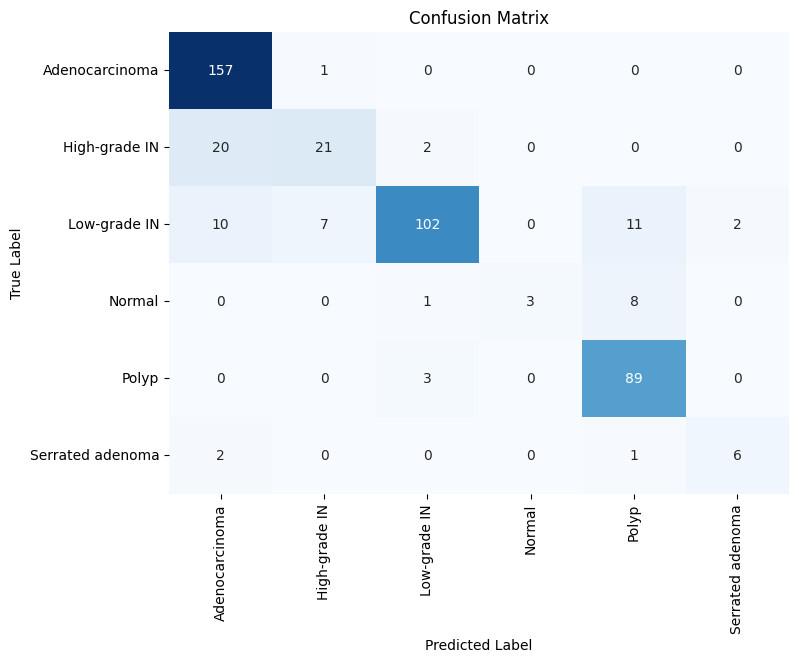

In [38]:
evaluate_model(model, val_dataloader, full_dataset_size, criterion, class_names=val_dataset.class_to_idx)